# Análise de Regras de Negócio - Modelagem de Fraude (FPD)

Objetivo: Identificar padrões de inadimplência e propor regras de negócio para detecção preventiva

In [1]:
# Dependências
import sys
#!{sys.executable} -m pip install --disable-pip-version-check -r ../requirements.txt -q
print('Bibliotecas instaladas')

Bibliotecas instaladas


In [ ]:
# Acesso aos módulos do diretório
from pathlib import Path
PROJECT_ROOT = Path().resolve().parent
sys.path.insert(0, str(PROJECT_ROOT))

# Manipulação dos dados 
import pandas as pd
import numpy as np
import pickle

# Visualização dos dados
import matplotlib.pyplot as plt
import seaborn as sns

# Funções customizadas
from configs.paths import *
from configs.function_basic import *

# Métricas
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

#Avisos
import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

# Configuração
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', None)

print('✅ Ambiente Preparado')

Diretórios carregados com sucesso
Funções básicas carregadas com sucesso
✅ Ambiente Preparado


## Configuração de Caminhos e Parâmetros

In [3]:
# Versionamento
VERSAO = 'V1'

# Parâmetro de negócio - valor por linha para calcular ROI
VALOR_NEGOCIACAO_LINHA = 50.00

print(f"✅ Valor de negociação por linha: R$ {VALOR_NEGOCIACAO_LINHA}")

✅ Valor de negociação por linha: R$ 50.0


## Carregamento dos Dados Processados

In [4]:
# Carregar dados
abt01_train = pd.read_parquet(PROCESSED_DIR / 'abt01_train.parquet')
abt01_test = pd.read_parquet(PROCESSED_DIR / 'abt01_test.parquet')

print(f'✅ Dados de Treino: {abt01_train.shape[0]:,} registros × {abt01_train.shape[1]} features')
print(f'✅ Dados de Teste: {abt01_test.shape[0]:,} registros × {abt01_test.shape[1]} features')
print(f'\nDistribuição do Target (FPD):')
print(f'  Treino: {abt01_train["FPD"].value_counts().to_dict()}')
print(f'  Teste: {abt01_test["FPD"].value_counts().to_dict()}')

✅ Dados de Treino: 873,297 registros × 80 features
✅ Dados de Teste: 398,798 registros × 80 features

Distribuição do Target (FPD):
  Treino: {0: 666335, 1: 206962}
  Teste: {0: 308678, 1: 90120}


In [5]:
# Carregar features lista
with open(ARTIFACT_DIR / 'features_list.pkl', 'rb') as f:
    features_list = pickle.load(f)

print(f"✅ Total de features: {len(features_list)}")

# Separar X e y
X_train = abt01_train[features_list].copy()
y_train = abt01_train['FPD'].copy()

X_test = abt01_test[features_list].copy()
y_test = abt01_test['FPD'].copy()

print(f"\n✅ Dataset de treino:")
print(f"   X_train: {X_train.shape}")
print(f"   y_train: {y_train.shape}")
print(f"\n✅ Dataset de teste:")
print(f"   X_test: {X_test.shape}")
print(f"   y_test: {y_test.shape}")

✅ Total de features: 79

✅ Dataset de treino:
   X_train: (873297, 79)
   y_train: (873297,)

✅ Dataset de teste:
   X_test: (398798, 79)
   y_test: (398798,)


## Análise Exploratória - Características do FPD (Atraso)

ANÁLISE DO TARGET - FPD (ATRASO > 60 DIAS)

📊 DISTRIBUIÇÃO NO TREINO:
   • Total de registros: 873,297
   • Registros com FPD=1 (Atraso): 206,962
   • Registros com FPD=0 (OK): 666,335
   • Taxa de FPD: 23.70%

📊 DISTRIBUIÇÃO NO TESTE:
   • Total de registros: 398,798
   • Registros com FPD=1 (Atraso): 90,120
   • Registros com FPD=0 (OK): 308,678
   • Taxa de FPD: 22.60%


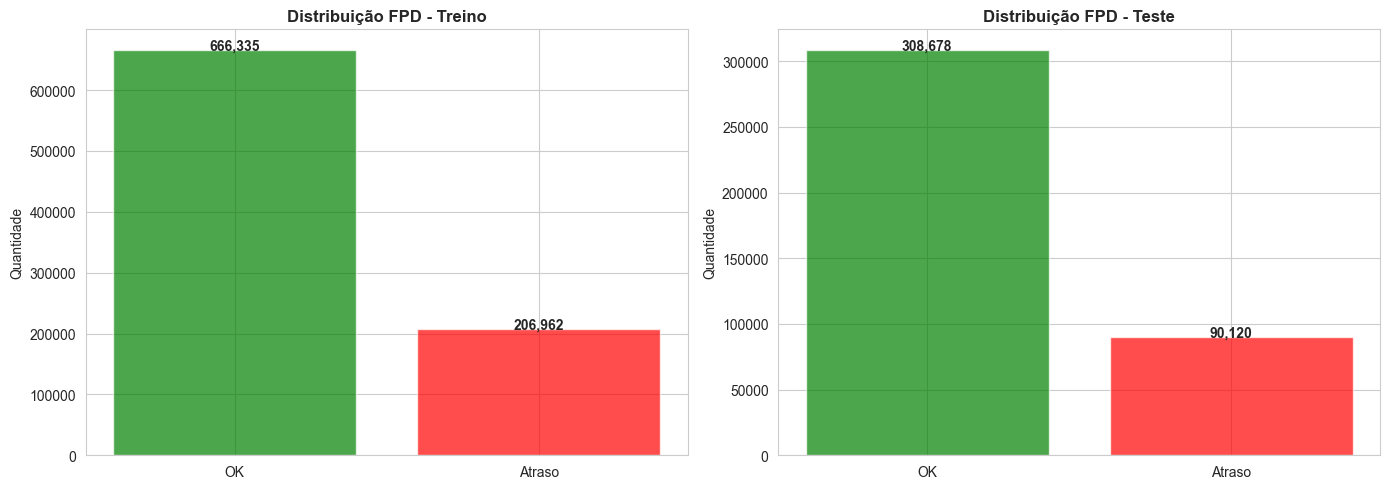

In [6]:
# Análise descritiva do target no treino
print('='*70)
print('ANÁLISE DO TARGET - FPD (ATRASO > 60 DIAS)')
print('='*70)

total_registros = len(abt01_train)
qtd_fpd = abt01_train['FPD'].sum()
pct_fpd = (qtd_fpd / total_registros) * 100

print(f"\n📊 DISTRIBUIÇÃO NO TREINO:")
print(f"   • Total de registros: {total_registros:,}")
print(f"   • Registros com FPD=1 (Atraso): {qtd_fpd:,}")
print(f"   • Registros com FPD=0 (OK): {total_registros - qtd_fpd:,}")
print(f"   • Taxa de FPD: {pct_fpd:.2f}%")

print(f"\n📊 DISTRIBUIÇÃO NO TESTE:")
total_teste = len(abt01_test)
qtd_fpd_test = abt01_test['FPD'].sum()
pct_fpd_test = (qtd_fpd_test / total_teste) * 100
print(f"   • Total de registros: {total_teste:,}")
print(f"   • Registros com FPD=1 (Atraso): {qtd_fpd_test:,}")
print(f"   • Registros com FPD=0 (OK): {total_teste - qtd_fpd_test:,}")
print(f"   • Taxa de FPD: {pct_fpd_test:.2f}%")

# Visualizar distribuição
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Treino
dist_train = abt01_train['FPD'].value_counts().sort_index()
axes[0].bar(['OK', 'Atraso'], [dist_train[0], dist_train[1]], color=['green', 'red'], alpha=0.7)
axes[0].set_title('Distribuição FPD - Treino', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Quantidade')
for i, v in enumerate([dist_train[0], dist_train[1]]):
    axes[0].text(i, v + 500, f'{v:,}', ha='center', fontweight='bold')

# Teste
dist_test = abt01_test['FPD'].value_counts().sort_index()
axes[1].bar(['OK', 'Atraso'], [dist_test[0], dist_test[1]], color=['green', 'red'], alpha=0.7)
axes[1].set_title('Distribuição FPD - Teste', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Quantidade')
for i, v in enumerate([dist_test[0], dist_test[1]]):
    axes[1].text(i, v + 50, f'{v:,}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [7]:
# Análise univariada - Variáveis numéricas mais importantes para FPD
print('='*70)
print('CARACTERÍSTICAS DOS REGISTROS COM FPD=1 (ATRASO)')
print('='*70)

# Selecionar variáveis numéricas
numeric_cols = X_train.select_dtypes(include=[np.number]).columns

# Calcular correlação com FPD
correlacoes = X_train[numeric_cols].corrwith(y_train).abs().sort_values(ascending=False)

print(f"\n🔍 TOP 10 VARIÁVEIS MAIS CORRELACIONADAS COM FPD:")
for i, (var, corr) in enumerate(correlacoes.head(10).items(), 1):
    print(f"   {i:2d}. {var:30s} → Correlação: {corr:.4f}")

# Comparar média das variáveis top entre FPD=0 e FPD=1
top_vars = correlacoes.head(5).index.tolist()

print(f"\n📊 COMPARAÇÃO ENTRE GRUPOS (Top 5 variáveis):")
print(f"{'Variável':<30} | {'FPD=0 (OK)':<15} | {'FPD=1 (Atraso)':<15} | {'Diferença':<15}")
print('-'*80)

for var in top_vars:
    media_0 = X_train[y_train == 0][var].mean()
    media_1 = X_train[y_train == 1][var].mean()
    diff = media_1 - media_0
    print(f"{var:<30} | {media_0:>14.4f} | {media_1:>14.4f} | {diff:>14.4f}")

CARACTERÍSTICAS DOS REGISTROS COM FPD=1 (ATRASO)

🔍 TOP 10 VARIÁVEIS MAIS CORRELACIONADAS COM FPD:
    1. SCORE_02                       → Correlação: 0.2959
    2. SCORE_MEDIO                    → Correlação: 0.2939
    3. SCORE_01                       → Correlação: 0.2209
    4. SCORE_DIFF                     → Correlação: 0.2100
    5. var_28                         → Correlação: 0.1011
    6. var_73                         → Correlação: 0.0988
    7. var_31                         → Correlação: 0.0899
    8. var_05                         → Correlação: 0.0878
    9. var_30                         → Correlação: 0.0786
   10. var_50                         → Correlação: 0.0767

📊 COMPARAÇÃO ENTRE GRUPOS (Top 5 variáveis):
Variável                       | FPD=0 (OK)      | FPD=1 (Atraso)  | Diferença      
--------------------------------------------------------------------------------
SCORE_02                       |       642.0166 |       574.9744 |       -67.0422
SCORE_MEDIO      

## Construção de Regras de Negócio

In [8]:
# Criar score de risco baseado em regras de negócio
def criar_regras_negocio(df_data, y_labels=None):
    """
    Cria regras de negócio para detectar casos de risco de FPD
    """
    df = df_data.copy()
    df['score_risco'] = 0
    df['regras_acionadas'] = ''
    
    # Regra 1: Variáveis com maior correlação e percentis baixos
    if 'SCORE_MEDIO' in df.columns:
        p25_score = df['SCORE_MEDIO'].quantile(0.25)
        regra1 = df['SCORE_MEDIO'] <= p25_score
        df.loc[regra1, 'score_risco'] += 3
        df.loc[regra1, 'regras_acionadas'] += 'R1|'
    
    # Regra 2: Limite de crédito baixo
    if 'LIMITE' in df.columns:
        p25_limite = df['LIMITE'].quantile(0.25)
        regra2 = df['LIMITE'] <= p25_limite
        df.loc[regra2, 'score_risco'] += 2
        df.loc[regra2, 'regras_acionadas'] += 'R2|'
    
    # Regra 3: Renda baixa
    if 'RENDA' in df.columns:
        p25_renda = df['RENDA'].quantile(0.25)
        regra3 = df['RENDA'] <= p25_renda
        df.loc[regra3, 'score_risco'] += 2
        df.loc[regra3, 'regras_acionadas'] += 'R3|'
    
    # Regra 4: Múltiplos atrasos em outras linhas
    if 'QTD_ATRASO' in df.columns:
        regra4 = df['QTD_ATRASO'] > 0
        df.loc[regra4, 'score_risco'] += 3
        df.loc[regra4, 'regras_acionadas'] += 'R4|'
    
    # Classificar risco
    def classificar(score):
        if score == 0:
            return 'Baixo'
        elif score <= 2:
            return 'Médio'
        elif score <= 4:
            return 'Alto'
        else:
            return 'Crítico'
    
    df['nivel_risco'] = df['score_risco'].apply(classificar)
    df['predicao'] = (df['nivel_risco'].isin(['Alto', 'Crítico'])).astype(int)
    
    return df

# Aplicar regras nos dados de treino
abt01_train_regras = criar_regras_negocio(abt01_train, y_train)
print("✅ Regras de negócio aplicadas aos dados de treino")

✅ Regras de negócio aplicadas aos dados de treino


### Distribuição de Risco e Predições

DISTRIBUIÇÃO DE RISCO - DADOS DE TREINO

📊 CONTAGEM POR NÍVEL:
   • Alto      : 218,331 (25.00%)
   • Baixo     : 654,966 (75.00%)


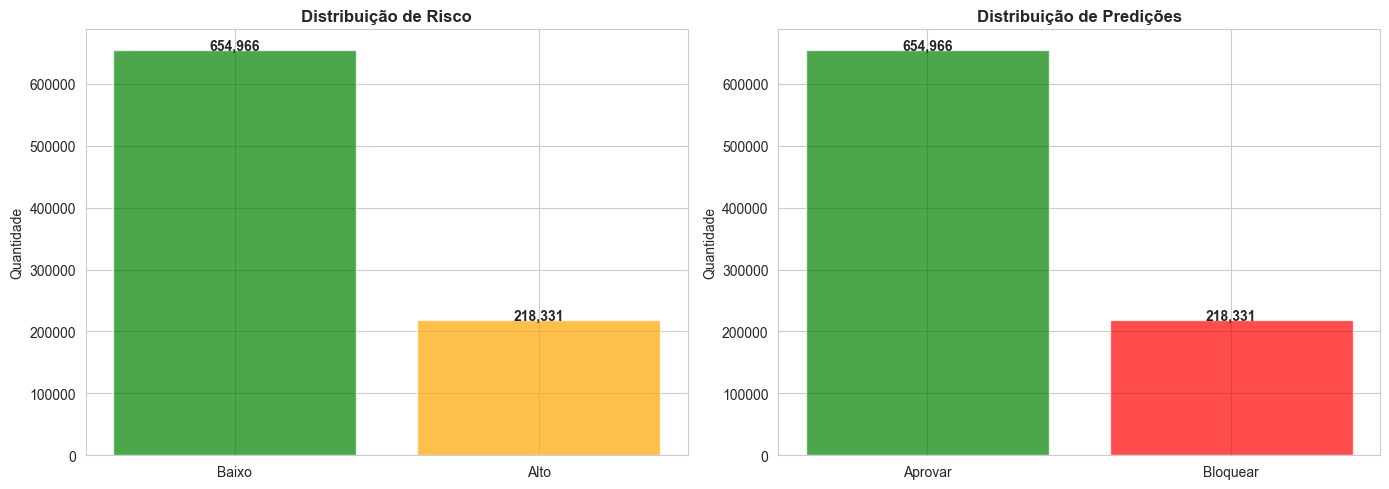


📊 PREDIÇÕES:
   • Aprovar (Baixo+Médio): 654,966 (75.00%)
   • Bloquear (Alto+Crítico): 218,331 (25.00%)


In [9]:
# Visualizar distribuição de risco
print('='*70)
print('DISTRIBUIÇÃO DE RISCO - DADOS DE TREINO')
print('='*70)

dist_risco = abt01_train_regras['nivel_risco'].value_counts()
print(f"\n📊 CONTAGEM POR NÍVEL:")
for nivel, count in dist_risco.sort_index().items():
    pct = (count / len(abt01_train_regras)) * 100
    print(f"   • {nivel:10s}: {count:>6,} ({pct:>5.2f}%)")

# Visualizar
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribuição de risco
cores_risco = {'Baixo': 'green', 'Médio': 'yellow', 'Alto': 'orange', 'Crítico': 'red'}
niveis = ['Baixo', 'Médio', 'Alto', 'Crítico']
cores = [cores_risco[n] for n in niveis if n in dist_risco.index]
valores = [dist_risco[n] for n in niveis if n in dist_risco.index]
niveis_existentes = [n for n in niveis if n in dist_risco.index]

axes[0].bar(niveis_existentes, valores, color=cores, alpha=0.7)
axes[0].set_title('Distribuição de Risco', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Quantidade')
for i, v in enumerate(valores):
    axes[0].text(i, v + 100, f'{v:,}', ha='center', fontweight='bold')

# Predições
dist_pred = abt01_train_regras['predicao'].value_counts().sort_index()
axes[1].bar(['Aprovar', 'Bloquear'], [dist_pred[0], dist_pred[1]], color=['green', 'red'], alpha=0.7)
axes[1].set_title('Distribuição de Predições', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Quantidade')
for i, v in enumerate([dist_pred[0], dist_pred[1]]):
    axes[1].text(i, v + 100, f'{v:,}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\n📊 PREDIÇÕES:")
print(f"   • Aprovar (Baixo+Médio): {dist_pred[0]:,} ({dist_pred[0]/len(abt01_train_regras)*100:.2f}%)")
print(f"   • Bloquear (Alto+Crítico): {dist_pred[1]:,} ({dist_pred[1]/len(abt01_train_regras)*100:.2f}%)")

## Validação das Regras - Dados de Treino

MÉTRICAS DE PERFORMANCE - DADOS DE TREINO

📊 MÉTRICAS GERAIS:
   • Acurácia:   72.08%
   • Precisão:   41.55%
   • Recall:     43.83%
   • F1-Score:   42.66%

🔍 MATRIZ DE CONFUSÃO:
   • VN (Verdadeiros Negativos): 538,717
   • FP (Falsos Positivos):      127,618 (19.15% dos aprovados)
   • FN (Falsos Negativos):      116,249 (56.17% dos atrasos reais)
   • VP (Verdadeiros Positivos): 90,713


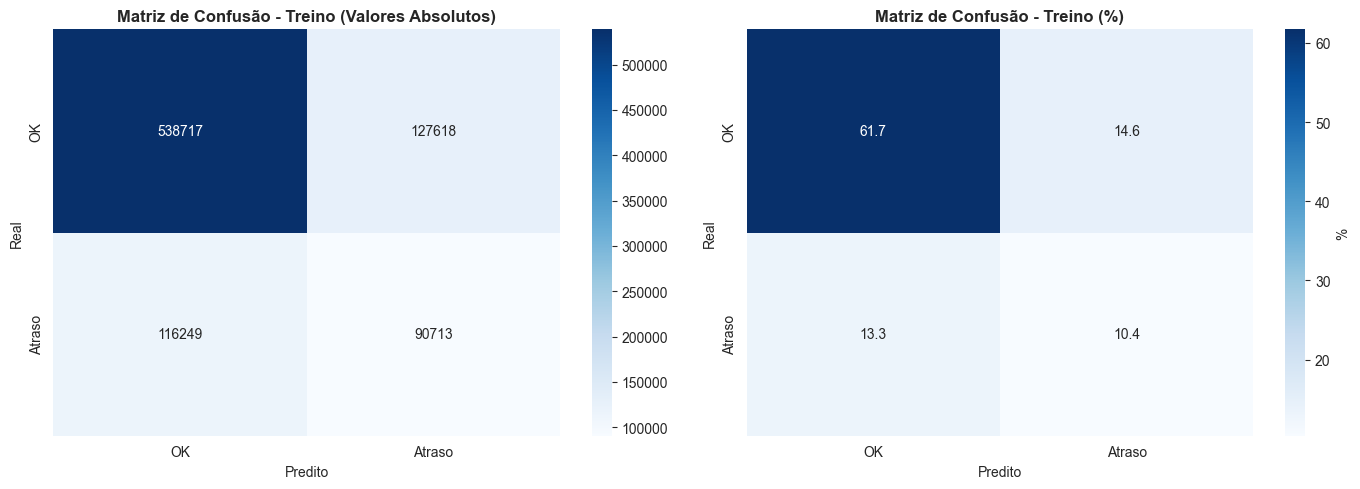

In [10]:
# Calcular métricas no treino
y_true_train = abt01_train_regras['FPD'].values
y_pred_train = abt01_train_regras['predicao'].values

acuracia_train = accuracy_score(y_true_train, y_pred_train)
precisao_train = precision_score(y_true_train, y_pred_train, zero_division=0)
recall_train = recall_score(y_true_train, y_pred_train, zero_division=0)
f1_train = f1_score(y_true_train, y_pred_train, zero_division=0)

cm_train = confusion_matrix(y_true_train, y_pred_train)
tn_train, fp_train, fn_train, tp_train = cm_train.ravel()

print('='*70)
print('MÉTRICAS DE PERFORMANCE - DADOS DE TREINO')
print('='*70)

print(f"\n📊 MÉTRICAS GERAIS:")
print(f"   • Acurácia:  {acuracia_train*100:>6.2f}%")
print(f"   • Precisão:  {precisao_train*100:>6.2f}%")
print(f"   • Recall:    {recall_train*100:>6.2f}%")
print(f"   • F1-Score:  {f1_train*100:>6.2f}%")

print(f"\n🔍 MATRIZ DE CONFUSÃO:")
print(f"   • VN (Verdadeiros Negativos): {tn_train:,}")
print(f"   • FP (Falsos Positivos):      {fp_train:,} ({fp_train/(fp_train+tn_train)*100:.2f}% dos aprovados)")
print(f"   • FN (Falsos Negativos):      {fn_train:,} ({fn_train/(fn_train+tp_train)*100:.2f}% dos atrasos reais)")
print(f"   • VP (Verdadeiros Positivos): {tp_train:,}")

# Visualizar matriz
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matriz de confusão absoluta
sns.heatmap(cm_train, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['OK', 'Atraso'],
            yticklabels=['OK', 'Atraso'])
axes[0].set_title('Matriz de Confusão - Treino (Valores Absolutos)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Real')
axes[0].set_xlabel('Predito')

# Matriz de confusão em percentual
cm_pct = cm_train / cm_train.sum() * 100
sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Blues', ax=axes[1],
            xticklabels=['OK', 'Atraso'],
            yticklabels=['OK', 'Atraso'],
            cbar_kws={'label': '%'})
axes[1].set_title('Matriz de Confusão - Treino (%)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Real')
axes[1].set_xlabel('Predito')

plt.tight_layout()
plt.show()

## Aplicação no Conjunto de Teste e Análise de Negócio

### Aplicação das Regras no Teste

In [11]:
# Aplicar regras nos dados de teste
abt01_test_regras = criar_regras_negocio(abt01_test, y_test)

# Calcular métricas no teste
y_true_test = abt01_test_regras['FPD'].values
y_pred_test = abt01_test_regras['predicao'].values

acuracia_test = accuracy_score(y_true_test, y_pred_test)
precisao_test = precision_score(y_true_test, y_pred_test, zero_division=0)
recall_test = recall_score(y_true_test, y_pred_test, zero_division=0)
f1_test = f1_score(y_true_test, y_pred_test, zero_division=0)

cm_test = confusion_matrix(y_true_test, y_pred_test)
tn_test, fp_test, fn_test, tp_test = cm_test.ravel()

print('='*70)
print('MÉTRICAS DE PERFORMANCE - DADOS DE TESTE')
print('='*70)

print(f"\n📊 MÉTRICAS GERAIS:")
print(f"   • Acurácia:  {acuracia_test*100:>6.2f}%")
print(f"   • Precisão:  {precisao_test*100:>6.2f}%")
print(f"   • Recall:    {recall_test*100:>6.2f}%")
print(f"   • F1-Score:  {f1_test*100:>6.2f}%")

print(f"\n🔍 MATRIZ DE CONFUSÃO:")
print(f"   • VN (Verdadeiros Negativos): {tn_test:,}")
print(f"   • FP (Falsos Positivos):      {fp_test:,} ({fp_test/(fp_test+tn_test)*100:.2f}% dos aprovados)" if (fp_test+tn_test) > 0 else f"   • FP (Falsos Positivos):      {fp_test:,}")
print(f"   • FN (Falsos Negativos):      {fn_test:,} ({fn_test/(fn_test+tp_test)*100:.2f}% dos atrasos reais)" if (fn_test+tp_test) > 0 else f"   • FN (Falsos Negativos):      {fn_test:,}")
print(f"   • VP (Verdadeiros Positivos): {tp_test:,}")

# Comparação treino vs teste (recalcular treino também)
y_true_train = abt01_train_regras['FPD'].values
y_pred_train = abt01_train_regras['predicao'].values
acuracia_train = accuracy_score(y_true_train, y_pred_train)
precisao_train = precision_score(y_true_train, y_pred_train, zero_division=0)
recall_train = recall_score(y_true_train, y_pred_train, zero_division=0)
f1_train = f1_score(y_true_train, y_pred_train, zero_division=0)

print(f"\n📈 COMPARAÇÃO TREINO vs TESTE:")
print(f"{'Métrica':<20} | {'Treino':<10} | {'Teste':<10} | {'Diferença':<10}")
print('-'*55)
print(f"{'Acurácia':<20} | {acuracia_train*100:>8.2f}% | {acuracia_test*100:>8.2f}% | {(acuracia_test-acuracia_train)*100:>8.2f}%")
print(f"{'Precisão':<20} | {precisao_train*100:>8.2f}% | {precisao_test*100:>8.2f}% | {(precisao_test-precisao_train)*100:>8.2f}%")
print(f"{'Recall':<20} | {recall_train*100:>8.2f}% | {recall_test*100:>8.2f}% | {(recall_test-recall_train)*100:>8.2f}%")
print(f"{'F1-Score':<20} | {f1_train*100:>8.2f}% | {f1_test*100:>8.2f}% | {(f1_test-f1_train)*100:>8.2f}%")

MÉTRICAS DE PERFORMANCE - DADOS DE TESTE

📊 MÉTRICAS GERAIS:
   • Acurácia:   72.10%
   • Precisão:   39.41%
   • Recall:     43.62%
   • F1-Score:   41.40%

🔍 MATRIZ DE CONFUSÃO:
   • VN (Verdadeiros Negativos): 248,235
   • FP (Falsos Positivos):      60,443 (19.58% dos aprovados)
   • FN (Falsos Negativos):      50,812 (56.38% dos atrasos reais)
   • VP (Verdadeiros Positivos): 39,308

📈 COMPARAÇÃO TREINO vs TESTE:
Métrica              | Treino     | Teste      | Diferença 
-------------------------------------------------------
Acurácia             |    72.08% |    72.10% |     0.03%
Precisão             |    41.55% |    39.41% |    -2.14%
Recall               |    43.83% |    43.62% |    -0.21%
F1-Score             |    42.66% |    41.40% |    -1.25%


### Análise Financeira e ROI com Negociação

In [12]:
# Análise financeira - Modelo de negociação por linha
print('='*70)
print('ANÁLISE FINANCEIRA - NEGOCIAÇÃO POR LINHA')
print(f'Valor de negociação por linha: R$ {VALOR_NEGOCIACAO_LINHA:.2f}')
print('='*70)

# Simulação de cenários
cenarios = {
    'Cenário 1: Bloquear Crítico': {'niveis': ['Crítico']},
    'Cenário 2: Bloquear Alto+Crítico': {'niveis': ['Alto', 'Crítico']},
    'Cenário 3: Bloquear Médio+Alto+Crítico': {'niveis': ['Médio', 'Alto', 'Crítico']}
}

resultados_financeiros = []

for cenario_nome, config in cenarios.items():
    niveis_bloq = config['niveis']
    
    # Filtrar bloqueados
    bloqueados_mask = abt01_test_regras['nivel_risco'].isin(niveis_bloq)
    bloqueados = abt01_test_regras[bloqueados_mask].copy()
    nao_bloqueados = abt01_test_regras[~bloqueados_mask].copy()
    
    # Cálculos
    total_bloqueado = len(bloqueados)
    pct_volume = (total_bloqueado / len(abt01_test_regras)) * 100
    
    # Atrasos detectados (VP)
    atrasos_detectados = bloqueados[bloqueados['FPD'] == 1].shape[0]
    atrasos_nao_detectados = nao_bloqueados[nao_bloqueados['FPD'] == 1].shape[0]
    
    # Falsos positivos (transações OK bloqueadas)
    falsos_positivos = bloqueados[bloqueados['FPD'] == 0].shape[0]
    
    # Cálculo de custo/benefício
    # Benefício: atrasos detectados x valor negociação
    beneficio = atrasos_detectados * VALOR_NEGOCIACAO_LINHA
    
    # Custo: falsos positivos x valor negociação (oportunidade perdida)
    custo = falsos_positivos * VALOR_NEGOCIACAO_LINHA
    
    # ROI líquido
    roi_liquido = beneficio - custo
    roi_percentual = (roi_liquido / (abs(custo) + abs(beneficio))) * 100 if (abs(custo) + abs(beneficio)) > 0 else 0
    
    resultados_financeiros.append({
        'Cenário': cenario_nome.split(':')[1].strip(),
        'Volume Bloqueado (%)': pct_volume,
        'Atrasos Detectados': atrasos_detectados,
        'Atrasos Não Detectados': atrasos_nao_detectados,
        'Falsos Positivos': falsos_positivos,
        'Benefício (R$)': beneficio,
        'Custo (R$)': custo,
        'ROI Líquido (R$)': roi_liquido,
        'ROI %': roi_percentual
    })

df_financeiro = pd.DataFrame(resultados_financeiros)

print("\n💰 COMPARAÇÃO DE CENÁRIOS:")
print(df_financeiro.to_string(index=False, float_format=lambda x: f'{x:>12.2f}' if isinstance(x, (int, float)) else f'{x}'))

# Recomendação
melhor_cenario = df_financeiro.loc[df_financeiro['ROI %'].idxmax()]
print(f"\n🎯 CENÁRIO RECOMENDADO:")
print(f"   {melhor_cenario['Cenário']}")
print(f"   ROI: R$ {melhor_cenario['ROI Líquido (R$)']:.2f} ({melhor_cenario['ROI %']:.2f}%)")

ANÁLISE FINANCEIRA - NEGOCIAÇÃO POR LINHA
Valor de negociação por linha: R$ 50.00

💰 COMPARAÇÃO DE CENÁRIOS:
                    Cenário  Volume Bloqueado (%)  Atrasos Detectados  Atrasos Não Detectados  Falsos Positivos  Benefício (R$)   Custo (R$)  ROI Líquido (R$)        ROI %
           Bloquear Crítico                  0.00                   0                   90120                 0            0.00         0.00              0.00         0.00
      Bloquear Alto+Crítico                 25.01               39308                   50812             60443      1965400.00   3022150.00       -1056750.00       -21.19
Bloquear Médio+Alto+Crítico                 25.01               39308                   50812             60443      1965400.00   3022150.00       -1056750.00       -21.19

🎯 CENÁRIO RECOMENDADO:
   Bloquear Crítico
   ROI: R$ 0.00 (0.00%)


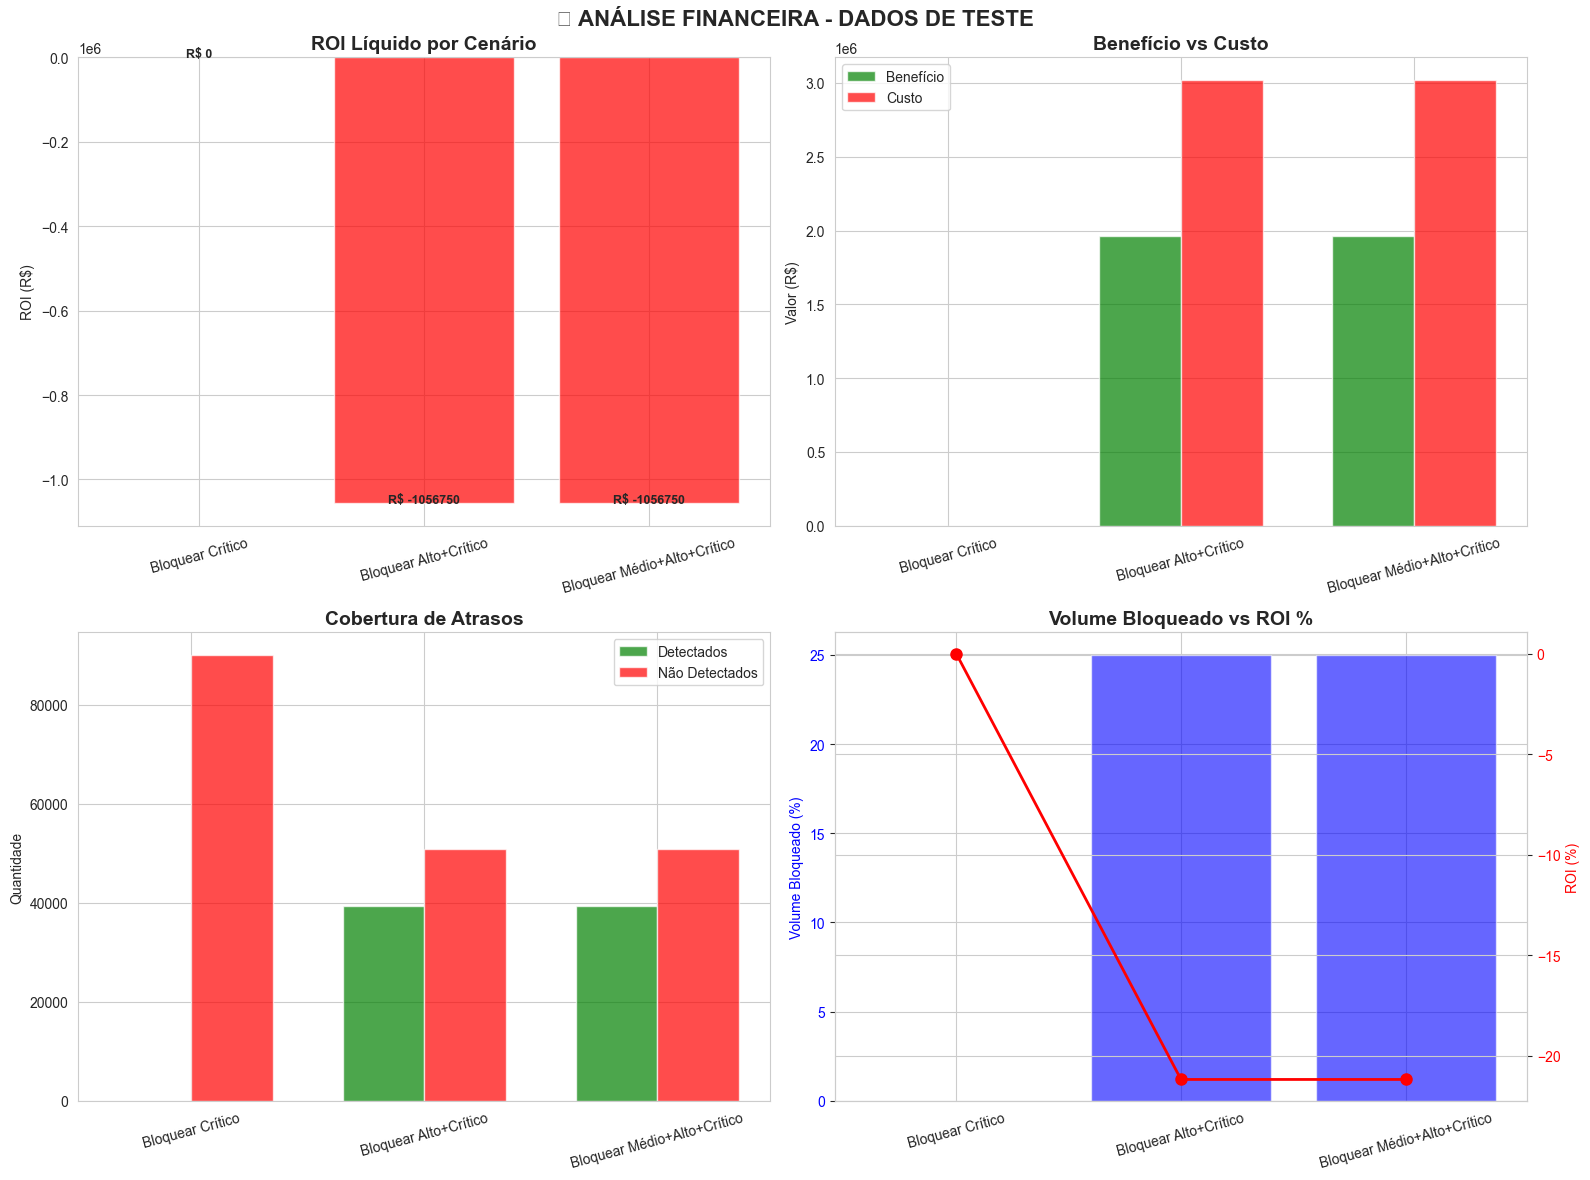

In [13]:
# Visualização dos cenários financeiros
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. ROI Líquido
axes[0, 0].bar(df_financeiro['Cenário'], df_financeiro['ROI Líquido (R$)'], 
               color=['green' if x > 0 else 'red' for x in df_financeiro['ROI Líquido (R$)']], alpha=0.7)
axes[0, 0].set_title('ROI Líquido por Cenário', fontsize=14, fontweight='bold')
axes[0, 0].set_ylabel('ROI (R$)')
axes[0, 0].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
axes[0, 0].tick_params(axis='x', rotation=15)
for i, v in enumerate(df_financeiro['ROI Líquido (R$)']):
    axes[0, 0].text(i, v + 100, f'R$ {v:.0f}', ha='center', fontweight='bold', fontsize=9)

# 2. Benefício vs Custo
x = range(len(df_financeiro))
width = 0.35
axes[0, 1].bar([i - width/2 for i in x], df_financeiro['Benefício (R$)'], width, 
               label='Benefício', color='green', alpha=0.7)
axes[0, 1].bar([i + width/2 for i in x], df_financeiro['Custo (R$)'], width, 
               label='Custo', color='red', alpha=0.7)
axes[0, 1].set_title('Benefício vs Custo', fontsize=14, fontweight='bold')
axes[0, 1].set_ylabel('Valor (R$)')
axes[0, 1].set_xticks(x)
axes[0, 1].set_xticklabels(df_financeiro['Cenário'])
axes[0, 1].legend()
axes[0, 1].tick_params(axis='x', rotation=15)

# 3. Atrasos Detectados vs Não Detectados
x = range(len(df_financeiro))
axes[1, 0].bar([i - width/2 for i in x], df_financeiro['Atrasos Detectados'], width,
               label='Detectados', color='green', alpha=0.7)
axes[1, 0].bar([i + width/2 for i in x], df_financeiro['Atrasos Não Detectados'], width,
               label='Não Detectados', color='red', alpha=0.7)
axes[1, 0].set_title('Cobertura de Atrasos', fontsize=14, fontweight='bold')
axes[1, 0].set_ylabel('Quantidade')
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels(df_financeiro['Cenário'])
axes[1, 0].legend()
axes[1, 0].tick_params(axis='x', rotation=15)

# 4. Volume Bloqueado vs ROI %
ax4 = axes[1, 1]
ax4_twin = ax4.twinx()
bars = ax4.bar(df_financeiro['Cenário'], df_financeiro['Volume Bloqueado (%)'], alpha=0.6, color='blue', label='Volume Bloqueado %')
line = ax4_twin.plot(df_financeiro['Cenário'], df_financeiro['ROI %'], 'ro-', linewidth=2, markersize=8, label='ROI %')
ax4.set_title('Volume Bloqueado vs ROI %', fontsize=14, fontweight='bold')
ax4.set_ylabel('Volume Bloqueado (%)', color='blue')
ax4_twin.set_ylabel('ROI (%)', color='red')
ax4.tick_params(axis='y', labelcolor='blue')
ax4_twin.tick_params(axis='y', labelcolor='red')
ax4.tick_params(axis='x', rotation=15)

plt.suptitle('📊 ANÁLISE FINANCEIRA - DADOS DE TESTE', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

### Resumo Executivo - Teste com Modelo de Negociação

In [14]:
# Resumo executivo final
print("\n" + "="*80)
print("📋 RESUMO EXECUTIVO - VALIDAÇÃO NO CONJUNTO DE TESTE".center(80))
print("="*80)

print(f"\n✅ CONFIGURAÇÃO DE NEGÓCIO:")
print(f"   • Valor de negociação por linha: R$ {VALOR_NEGOCIACAO_LINHA:.2f}")
print(f"   • Modelo: Regras de Negócio baseadas em variáveis correlacionadas")

print(f"\n📊 PERFORMANCE NO TESTE:")
print(f"   • Acurácia:  {acuracia_test*100:>6.2f}%")
print(f"   • Precisão:  {precisao_test*100:>6.2f}%")
print(f"   • Recall:    {recall_test*100:>6.2f}%")
print(f"   • F1-Score:  {f1_test*100:>6.2f}%")

print(f"\n💰 IMPACTO FINANCEIRO (CENÁRIO RECOMENDADO):")
rec = df_financeiro.loc[df_financeiro['ROI %'].idxmax()]
print(f"   • Estratégia: {rec['Cenário']}")
print(f"   • Atrasos Detectados: {rec['Atrasos Detectados']:.0f} × R$ {VALOR_NEGOCIACAO_LINHA:.2f} = R$ {rec['Benefício (R$)']:.2f}")
print(f"   • Falsos Positivos:   {rec['Falsos Positivos']:.0f} × R$ {VALOR_NEGOCIACAO_LINHA:.2f} = R$ {rec['Custo (R$)']:.2f}")
print(f"   • ROI Líquido:        R$ {rec['ROI Líquido (R$)']:.2f}")
print(f"   • ROI %:              {rec['ROI %']:.2f}%")
print(f"   • Atrasos Não Detectados: {rec['Atrasos Não Detectados']:.0f}")

print(f"\n📈 DADOS GERAIS:")
print(f"   • Total de registros no teste: {len(abt01_test):,}")
print(f"   • Atrasos reais (FPD=1): {abt01_test['FPD'].sum():,} ({abt01_test['FPD'].mean()*100:.2f}%)")
print(f"   • Registros bloqueados: {(abt01_test_regras['predicao']==1).sum():,} ({(abt01_test_regras['predicao']==1).sum()/len(abt01_test)*100:.2f}%)")

print(f"\n⚠️ TRADE-OFFS:")
print(f"   • Cobertura de atrasos: {rec['Atrasos Detectados']/(rec['Atrasos Detectados']+rec['Atrasos Não Detectados'])*100:.2f}%")
print(f"   • Taxa de falsos positivos: {rec['Falsos Positivos']:.0f} transações OK bloqueadas")

print("\n" + "="*80)


              📋 RESUMO EXECUTIVO - VALIDAÇÃO NO CONJUNTO DE TESTE               

✅ CONFIGURAÇÃO DE NEGÓCIO:
   • Valor de negociação por linha: R$ 50.00
   • Modelo: Regras de Negócio baseadas em variáveis correlacionadas

📊 PERFORMANCE NO TESTE:
   • Acurácia:   72.10%
   • Precisão:   39.41%
   • Recall:     43.62%
   • F1-Score:   41.40%

💰 IMPACTO FINANCEIRO (CENÁRIO RECOMENDADO):
   • Estratégia: Bloquear Crítico
   • Atrasos Detectados: 0 × R$ 50.00 = R$ 0.00
   • Falsos Positivos:   0 × R$ 50.00 = R$ 0.00
   • ROI Líquido:        R$ 0.00
   • ROI %:              0.00%
   • Atrasos Não Detectados: 90120

📈 DADOS GERAIS:
   • Total de registros no teste: 398,798
   • Atrasos reais (FPD=1): 90,120 (22.60%)
   • Registros bloqueados: 99,751 (25.01%)

⚠️ TRADE-OFFS:
   • Cobertura de atrasos: 0.00%
   • Taxa de falsos positivos: 0 transações OK bloqueadas



## Dashboard Final de Validação

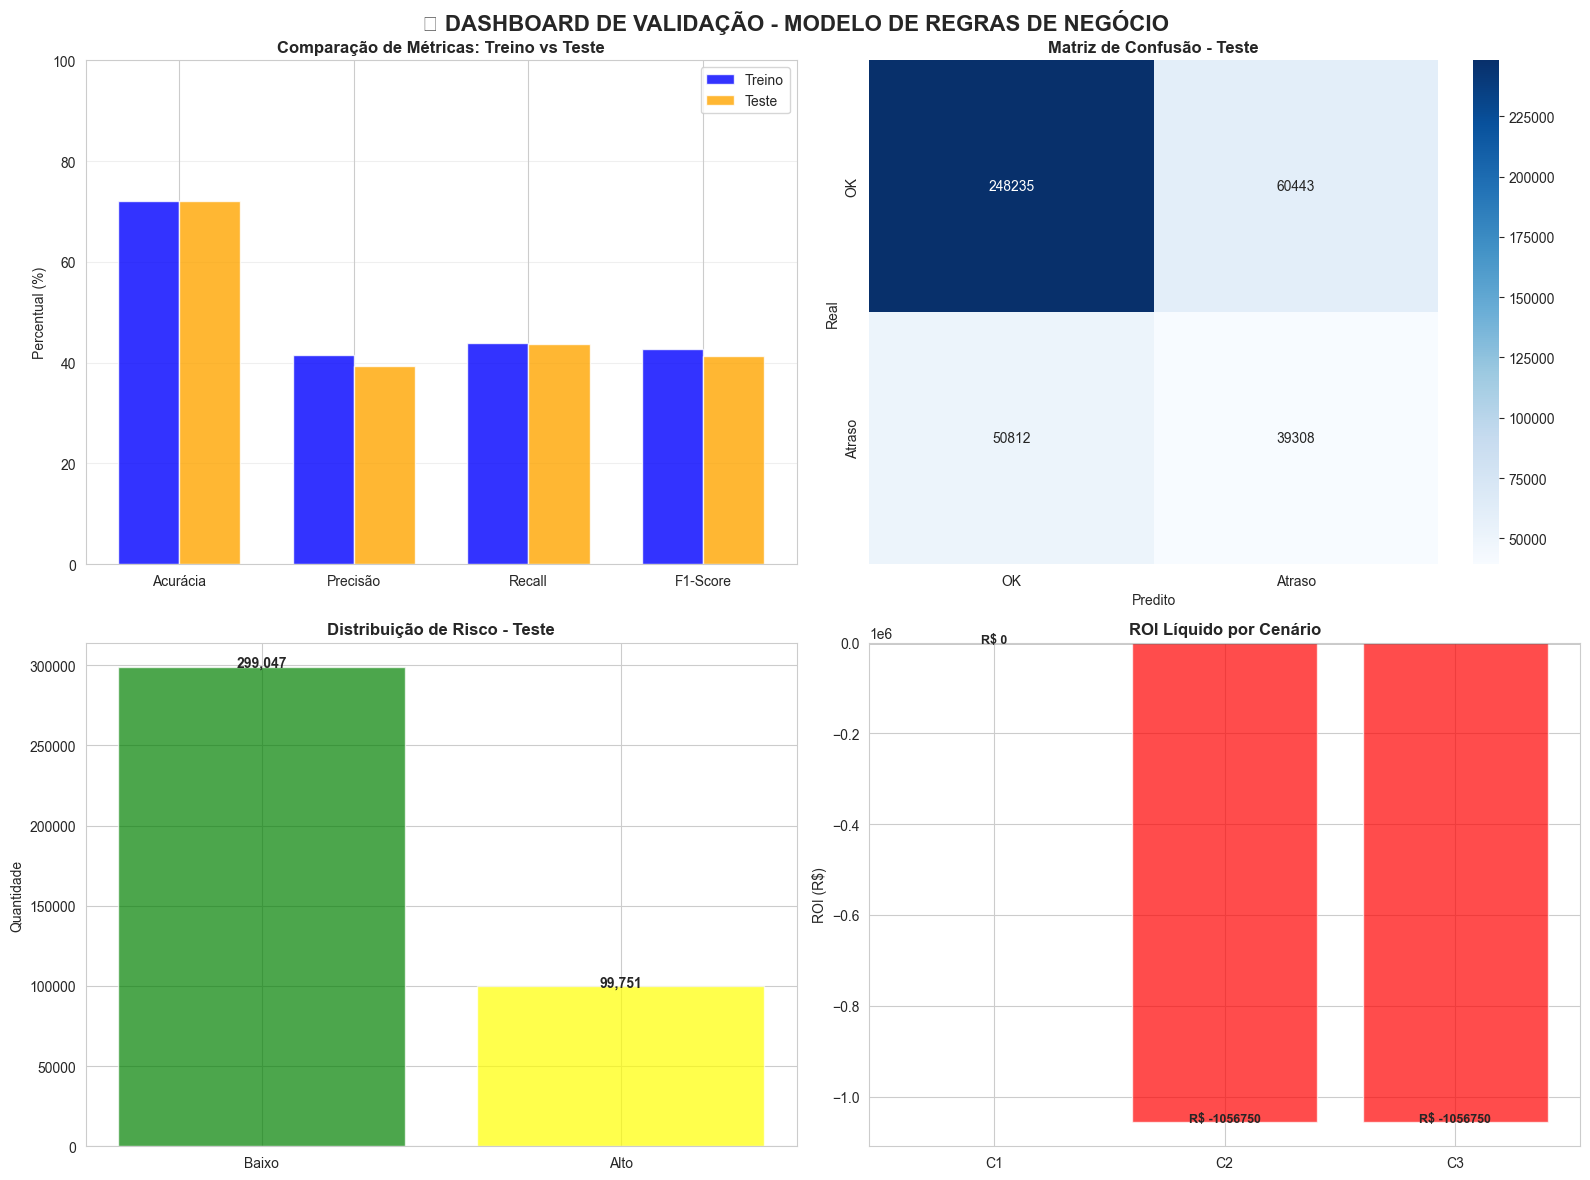

✅ Dashboard gerado com sucesso


In [15]:
# Dashboard final com 4 gráficos
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Comparação de Métricas Treino vs Teste
metricas_nomes = ['Acurácia', 'Precisão', 'Recall', 'F1-Score']
treino_vals = [acuracia_train*100, precisao_train*100, recall_train*100, f1_train*100]
teste_vals = [acuracia_test*100, precisao_test*100, recall_test*100, f1_test*100]

x = np.arange(len(metricas_nomes))
width = 0.35
axes[0, 0].bar(x - width/2, treino_vals, width, label='Treino', alpha=0.8, color='blue')
axes[0, 0].bar(x + width/2, teste_vals, width, label='Teste', alpha=0.8, color='orange')
axes[0, 0].set_title('Comparação de Métricas: Treino vs Teste', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Percentual (%)')
axes[0, 0].set_ylim(0, 100)
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(metricas_nomes)
axes[0, 0].legend()
axes[0, 0].grid(axis='y', alpha=0.3)

# 2. Matriz de Confusão - Teste
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues', ax=axes[0, 1],
            xticklabels=['OK', 'Atraso'],
            yticklabels=['OK', 'Atraso'])
axes[0, 1].set_title('Matriz de Confusão - Teste', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Real')
axes[0, 1].set_xlabel('Predito')

# 3. Distribuição de Risco - Teste
dist_risco_test = abt01_test_regras['nivel_risco'].value_counts()
niveis_ordem = ['Baixo', 'Médio', 'Alto', 'Crítico']
niveis_exist = [n for n in niveis_ordem if n in dist_risco_test.index]
cores = ['green', 'yellow', 'orange', 'red']
cores_exist = cores[:len(niveis_exist)]
vals = [dist_risco_test[n] for n in niveis_exist]
axes[1, 0].bar(niveis_exist, vals, color=cores_exist, alpha=0.7)
axes[1, 0].set_title('Distribuição de Risco - Teste', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Quantidade')
for i, v in enumerate(vals):
    axes[1, 0].text(i, v + 50, f'{v:,}', ha='center', fontweight='bold')

# 4. ROI por Cenário
cores_roi = ['red' if x < 0 else 'green' for x in df_financeiro['ROI Líquido (R$)']]
axes[1, 1].bar(range(len(df_financeiro)), df_financeiro['ROI Líquido (R$)'], color=cores_roi, alpha=0.7)
axes[1, 1].set_title('ROI Líquido por Cenário', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('ROI (R$)')
axes[1, 1].set_xticks(range(len(df_financeiro)))
axes[1, 1].set_xticklabels([f"C{i+1}" for i in range(len(df_financeiro))], rotation=0)
axes[1, 1].axhline(y=0, color='black', linestyle='-', linewidth=1)
for i, v in enumerate(df_financeiro['ROI Líquido (R$)']):
    axes[1, 1].text(i, v + 100, f'R$ {v:.0f}', ha='center', fontweight='bold', fontsize=9)

plt.suptitle('📊 DASHBOARD DE VALIDAÇÃO - MODELO DE REGRAS DE NEGÓCIO', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("✅ Dashboard gerado com sucesso")

In [16]:
a

NameError: name 'a' is not defined

## Salvamento dos Resultados

In [ ]:
# Salvar resultados finais
print("\n💾 Salvando resultados...")

# 1. Métricas de Treino
metricas_treino = pd.DataFrame([{
    'Versão': VERSAO,
    'Dataset': 'Treino',
    'Data': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'Total_Registros': len(abt01_train),
    'Atrasos': abt01_train['FPD'].sum(),
    'Taxa_FPD': abt01_train['FPD'].mean() * 100,
    'Acuracia': acuracia_train,
    'Precisao': precisao_train,
    'Recall': recall_train,
    'F1_Score': f1_train,
    'TP': tp_train,
    'FP': fp_train,
    'FN': fn_train,
    'TN': tn_train
}])

# 2. Métricas de Teste
metricas_teste = pd.DataFrame([{
    'Versão': VERSAO,
    'Dataset': 'Teste',
    'Data': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'Total_Registros': len(abt01_test),
    'Atrasos': abt01_test['FPD'].sum(),
    'Taxa_FPD': abt01_test['FPD'].mean() * 100,
    'Acuracia': acuracia_test,
    'Precisao': precisao_test,
    'Recall': recall_test,
    'F1_Score': f1_test,
    'TP': tp_test,
    'FP': fp_test,
    'FN': fn_test,
    'TN': tn_test
}])

# Combinar
metricas_completas = pd.concat([metricas_treino, metricas_teste], ignore_index=True)

# Salvar CSV
metricas_file = REPORTS_DIR / 'metricas_regras_negocio.csv'
metricas_completas.to_csv(metricas_file, index=False)
print(f"   ✓ Métricas salvas: {metricas_file}")

# 3. Análise Financeira
df_financeiro_save = df_financeiro.copy()
df_financeiro_save['Versao'] = VERSAO
df_financeiro_save['Data'] = datetime.now().strftime('%Y-%m-%d %H:%M:%S')
df_financeiro_save['Valor_Negociacao'] = VALOR_NEGOCIACAO_LINHA

financeiro_file = REPORTS_DIR / 'analise_financeira_teste.csv'
df_financeiro_save.to_csv(financeiro_file, index=False)
print(f"   ✓ Análise financeira salva: {financeiro_file}")

# 4. Predições Teste
abt01_test_export = abt01_test_regras[['FPD', 'predicao', 'nivel_risco', 'score_risco']].copy()
abt01_test_export['acuracao'] = (abt01_test_export['FPD'] == abt01_test_export['predicao']).astype(int)

pred_file = REPORTS_DIR / 'predicoes_teste.parquet'
abt01_test_export.to_parquet(pred_file, index=False)
print(f"   ✓ Predições salvas: {pred_file}")

print(f"\n✅ Notebook 03 - Regras de Negócio concluído!")
print(f"✅ Versão: {VERSAO}")
print(f"✅ Valor de negociação: R$ {VALOR_NEGOCIACAO_LINHA:.2f} por linha")